# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**

1. Пусть $x=(x_1,x_2)^\top$ и $y=(y_1,y_2)^\top$ принадлежат множеству, то есть $x_2\ge x_1^2$ и $y_2\ge y_1^2$. Для $t\in[0,1]$ положим $z=tx+(1-t)y$. Тогда

   $$
   \begin{aligned}
   z_2-z_1^2
   &\ge tx_1^2+(1-t)y_1^2-\bigl(tx_1+(1-t)y_1\bigr)^2\\
   &=t(1-t)(x_1-y_1)^2\ge 0.
   \end{aligned}
   $$

   Следовательно, $z_2\ge z_1^2$, и множество выпукло.

2. Пусть $\lVert Ax-b\rVert_2\le1$ и $\lVert Ay-b\rVert_2\le1$. Для $z=tx+(1-t)y$, где $t\in[0,1]$, по неравенству треугольника

   $$
   \begin{aligned}
   \lVert Az-b\rVert_2
   &=\lVert t(Ax-b)+(1-t)(Ay-b)\rVert_2\\
   &\le t\lVert Ax-b\rVert_2+(1-t)\lVert Ay-b\rVert_2\le1.
   \end{aligned}
   $$

   Значит, множество выпукло.

3. Точки $x=(1,0)^\top$ и $y=(-1,0)^\top$ принадлежат множеству, но их середина $z=(x+y)/2=(0,0)^\top$ ему не принадлежит, поскольку $\lVert z\rVert_2=0<1$. Множество не выпукло.

**(б)**

**Ответ:**

1. Гессиан функции $f$ имеет вид

   $$
   \nabla^2 f(x)=\begin{pmatrix}2&a\\a&2\end{pmatrix},
   \qquad \lambda_{1,2}=2\pm a.
   $$

   Он положительно полуопределён при $|a|\le2$ и положительно определён при $|a|<2$. Поэтому $f$ выпукла при $|a|\le2$ и строго выпукла при $|a|<2$. При $a=-2$ функция постоянна на отрезке от $(0,0)^\top$ до $(1,1)^\top$, а при $a=2$ — на отрезке от $(0,0)^\top$ до $(1,-1)^\top$, поэтому на границе строгой выпуклости нет. При $|a|>2$ функция не выпукла.

2. Для $g(x)=x_1^2x_2^2$

   $$
   \nabla^2 g(x)=\begin{pmatrix}
   2x_2^2&4x_1x_2\\
   4x_1x_2&2x_1^2
   \end{pmatrix},
   \qquad \det\nabla^2g(x)=-12x_1^2x_2^2.
   $$

   В точке $(1,1)^\top$ определитель отрицателен, поэтому гессиан не является положительно полуопределённым и $g$ не выпукла.

In [2]:
for a_value in [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    hessian = np.array([[2.0, a_value], [a_value, 2.0]])
    eigenvalues = np.linalg.eigvalsh(hessian)
    print(f"a = {a_value:4.1f}, eigenvalues = {eigenvalues}, "
          f"convex = {np.all(eigenvalues >= -1e-12)}, "
          f"strictly convex = {np.all(eigenvalues > 1e-12)}")


a = -3.0, eigenvalues = [-1.  5.], convex = False, strictly convex = False
a = -2.0, eigenvalues = [0. 4.], convex = True, strictly convex = False
a = -1.0, eigenvalues = [1. 3.], convex = True, strictly convex = True
a =  0.0, eigenvalues = [2. 2.], convex = True, strictly convex = True
a =  1.0, eigenvalues = [1. 3.], convex = True, strictly convex = True
a =  2.0, eigenvalues = [0. 4.], convex = True, strictly convex = False
a =  3.0, eigenvalues = [-1.  5.], convex = False, strictly convex = False


**(в)**

**Ответ:**

1. Функция $x\mapsto\lVert Ax-b\rVert_2$ выпукла как норма от аффинного отображения. Кроме того, $\lVert x\rVert_\infty=\max_i|x_i|$ выпукла как максимум выпуклых функций. При $\lambda\ge0$ их сумма $\lVert Ax-b\rVert_2+\lambda\lVert x\rVert_\infty$ выпукла.

2. Для $f_i(x)=(a_i^\top x-b_i)^2$ имеем

   $$
   \nabla^2 f_i(x)=2a_i a_i^\top,
   \qquad v^\top\nabla^2 f_i(x)v=2(a_i^\top v)^2\ge0.
   $$

   Каждая $f_i$ выпукла, значит, $f(x)=\max_i f_i(x)$ также выпукла.

3. Правило композиции с убывающей функцией $u\mapsto e^{-u}$ не доказывает выпуклость $e^{-\lVert x\rVert_2^2}$. Более того, при $x=(0,1)^\top$ и $y=(1,0)^\top$

   $$
   f(x)=f(y)=e^{-1},\qquad
   f\!\left(\frac{x+y}{2}\right)=e^{-1/2}>\frac{f(x)+f(y)}2=e^{-1}.
   $$

   Поэтому функция не выпукла.

**Гладкость.** Первая функция негладкая: модуль $|x_i|$ не имеет производной при $x_i=0$, поэтому функция негладкая в $x=0$. Вторая функция негладкая: максимум может не иметь производной там, где значения разных $f_i$ равны, а их производные различаются. Третья функция гладкая.

**(г)**

**Ответ:**

**(а)** В целевой функции $Q=I$, а ограничения линейны, поэтому задача выпукла.

**(б)** Целевая функция и ограничения линейны, поэтому задача выпукла.

**(в)** Допустимое множество задаётся равенством $g(x)=\lVert x\rVert_2^2-1=0$ и представляет собой окружность. Оно не выпукло, поэтому задача не является выпуклой.

**(г)** Ограничений нет. При $x_1\ne0$ и $x_2=0$ функция периодична по $x_3$, но не постоянна. Выпуклая периодическая функция должна быть постоянной, поэтому задача невыпукла.

**(д)** Введём переменные $s_i$ и ограничения $-s_i\le a_i^\top x-b_i\le s_i$. Тогда задача принимает вид $\min_{x,s}\max_i s_i$. Ограничения линейны, а максимум аффинных функций выпуклый, поэтому задача выпукла.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:**

Обозначим проекцию через $x^*$. Она лежит на границе полупространства: если бы $a^\top x^*<b$, то из условия оптимальности для всех направлений следовало бы $\nabla f(x^*)=x^*-p=0$, но $p\notin\Omega$.

Для любого $v$ с $a^\top v=0$ обе точки $x^*+v$ и $x^*-v$ допустимы. Условие оптимальности для этих точек даёт $(x^*-p)^\top v=0$. Значит, $x^*-p=ca$ для некоторого $c\in\mathbb R$. Из $a^\top x^*=b$ получаем

$$
c\lVert a\rVert_2^2=b-a^\top p,
\qquad
c=-\frac{a^\top p-b}{\lVert a\rVert_2^2}<0,
\qquad
x^*=p-\frac{a^\top p-b}{\lVert a\rVert_2^2}\,a.
$$

Наконец, для любого $y\in\Omega$ выполнено $a^\top(y-x^*)\le0$, поэтому

$$
\nabla f(x^*)^\top(y-x^*)
=c\,a^\top(y-x^*)\ge0.
$$

Таким образом, найденная точка удовлетворяет условию оптимальности и является проекцией.

**Численная проверка (пункты 2 и 3)**

In [4]:
x_formula = p - ((a @ p - b) / (a @ a)) * a

result = minimize(
    fun=lambda x: 0.5 * np.dot(x - p, x - p),
    x0=np.zeros_like(p),
    jac=lambda x: x - p,
    method="SLSQP",
    constraints=[{"type": "ineq", "fun": lambda x: b - a @ x,
                  "jac": lambda x: -a}],
)
assert result.success, result.message
print("Formula:", x_formula)
print("SLSQP:  ", result.x)
print("Difference:", np.linalg.norm(result.x - x_formula))

points = rng.normal(size=(1998, len(p)))
violation = np.maximum((points @ a - b) / (a @ a), 0.0) + 1e-8
points = points - violation[:, None] * a
points = np.vstack([points, x_formula, np.zeros_like(p)])
assert np.all(points @ a <= b + 1e-12)

optimality_at_projection = (points - x_formula) @ (x_formula - p)
optimality_at_zero = points @ (-p)
print("Min optimality value at projection:", optimality_at_projection.min())
print("Min optimality value at x = 0:", optimality_at_zero.min())

tolerance = 1e-10
for name, values in [
    ("projection", optimality_at_projection),
    ("x = 0", optimality_at_zero),
]:
    negative = np.count_nonzero(values < -tolerance)
    zero = np.count_nonzero(np.abs(values) <= tolerance)
    positive = np.count_nonzero(values > tolerance)
    print(f"{name}: negative = {negative}, zero = {zero}, positive = {positive}")


Formula: [ 2.41666667 -0.16666667  1.08333333]
SLSQP:   [ 2.41666667 -0.16666667  1.08333333]
Difference: 8.308148362110449e-16
Min optimality value at projection: 0.0
Min optimality value at x = 0: -9.890435979555072
projection: negative = 0, zero = 1, positive = 1999
x = 0: negative = 874, zero = 1, positive = 1125


**Ответ:** Если знак положителен, то значит в направлении выбранной точки y из множества функция растёт и между $x^*$ и y существует точка $x^* + h$, что $f(x^*+h) > f(x^*)$

Если знак отрицателен, то в направлении выбранной точки y существует точка $x^* + h$, что $f(x*+h) < f(x*)$, а значит $x^*$ не является оптимальным.


**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

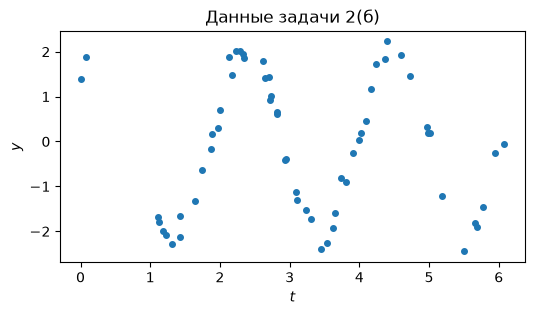

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:**

**A.** Это нелинейная задача без ограничений (NLP). При $x_1\ne0$ и $x_2=0$ функция периодична по $x_3$, но не постоянна. Выпуклая периодическая функция должна быть постоянной, поэтому задача невыпукла.

**B.** Это квадратичная задача без ограничений (QP). Каждая невязка $x_1\sin(\omega t_i)+x_2\cos(\omega t_i)-y_i$ является аффинной функцией от $x$. Её квадрат выпуклый, а сумма таких квадратов тоже выпукла. Значит, задача выпукла.

**Мультистарт (пункт 2)**

Start 01: A = 1.13927310, B = 1.14076401
Start 02: A = 63.82489066, B = 1.14076401
Start 03: A = 1.13927310, B = 1.14076401
Start 04: A = 1.13927310, B = 1.14076401
Start 05: A = 1.13927310, B = 1.14076401
Start 06: A = 61.49727344, B = 1.14076401
Start 07: A = 61.49727344, B = 1.14076401
Start 08: A = 64.25177556, B = 1.14076401
Start 09: A = 1.13927310, B = 1.14076401
Start 10: A = 63.82489068, B = 1.14076401
Start 11: A = 1.13927310, B = 1.14076401
Start 12: A = 1.13927310, B = 1.14076401
Start 13: A = 61.49727344, B = 1.14076401
Start 14: A = 1.13927310, B = 1.14076401
Start 15: A = 64.25177556, B = 1.14076401
Start 16: A = 1.13927310, B = 1.14076401
Start 17: A = 61.68817068, B = 1.14076401
Start 18: A = 1.13927310, B = 1.14076401
Start 19: A = 61.49727344, B = 1.14076401
Start 20: A = 1.13927310, B = 1.14076401
A: best f = 1.139273097803334 fraction = 0.55
B: best f = 1.1407640089470723 fraction = 1.0
B coefficients: [1.6234269  1.33780773]
Amplitude from B: 2.103626497732764
Pha

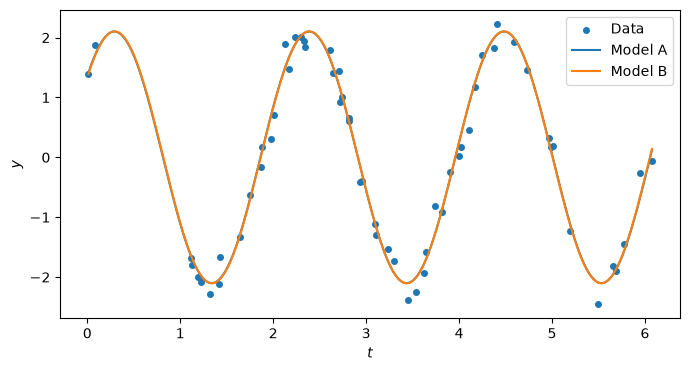

In [6]:
design = np.column_stack([np.sin(omega * t), np.cos(omega * t)])

def objective_A(x):
    phase = x[1] * t + x[2]
    residual = x[0] * np.sin(phase) - y
    return 0.5 * residual @ residual

def gradient_A(x):
    phase = x[1] * t + x[2]
    residual = x[0] * np.sin(phase) - y
    return np.array([
        residual @ np.sin(phase),
        residual @ (x[0] * t * np.cos(phase)),
        residual @ (x[0] * np.cos(phase)),
    ])

def objective_B(x):
    residual = design @ x - y
    return 0.5 * residual @ residual

def gradient_B(x):
    return design.T @ (design @ x - y)

results_A = [minimize(objective_A, x0, jac=gradient_A, method="BFGS")
             for x0 in starts]
results_B = [minimize(objective_B, x0[:2], jac=gradient_B, method="BFGS")
             for x0 in starts]
values_A = np.array([result.fun for result in results_A])
values_B = np.array([result.fun for result in results_B])

for i, (value_A, value_B) in enumerate(zip(values_A, values_B), start=1):
    print(f"Start {i:02d}: A = {value_A:.8f}, B = {value_B:.8f}")

best_A = results_A[np.argmin(values_A)]
best_B = results_B[np.argmin(values_B)]
print("A: best f =", values_A.min(),
      "fraction =", np.mean(np.isclose(values_A, values_A.min(), rtol=1e-4, atol=1e-6)))
print("B: best f =", values_B.min(),
      "fraction =", np.mean(np.isclose(values_B, values_B.min(), rtol=1e-4, atol=1e-6)))
print("B coefficients:", best_B.x)
print("Amplitude from B:", np.hypot(*best_B.x))
print("Phase from B:", np.arctan2(best_B.x[1], best_B.x[0]))

t_grid = np.linspace(t.min(), t.max(), 500)
fit_A = best_A.x[0] * np.sin(best_A.x[1] * t_grid + best_A.x[2])
fit_B = best_B.x[0] * np.sin(omega * t_grid) + best_B.x[1] * np.cos(omega * t_grid)
plt.figure(figsize=(8, 4))
plt.scatter(t, y, s=16, label="Data")
plt.plot(t_grid, fit_A, label="Model A")
plt.plot(t_grid, fit_B, label="Model B")
plt.xlabel("$t$")
plt.ylabel("$y$")
plt.legend()
plt.show()


**Объяснение (пункт 3)**

**Ответ:**  Так как задача B - выпуклая, то она имеет всего 1 глобальным и локальный минимум. К которому постоянно приходет solver scipy. Задача A - не выпуклая, поэтому у неё несколько локальных минимумов, и в зависимости от старта можно прийти к разным решениям.
Перевод из задачи B в задачу A:
Пусть решение B равно $(u,v)$. Тогда амплитуда и фаза для A находятся из равенства
$$
u\sin(3t)+v\cos(3t)=R\sin(3t+\phi),
\qquad
R=\sqrt{u^2+v^2},\quad \phi=\operatorname{atan2}(v,u).
$$
Поскольку точки были сгенерированны случайно, то частота $\omega = 3$ не является оптимальным ответом для данной выборки. Однако с увеличением выборки оптимальная частота будет всё ближе к 3, т.е. решение из задачи B будет лучше распространятся на новые данные и следовательно решение B лучше.


## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:** Обозначим $u=P(p)$ и $v=P(q)$. Из условия оптимальности для $u$ с пробной точкой $v$ и для $v$ с пробной точкой $u$ получаем

$$
(u-p)^\top(v-u)\ge0,
\qquad
(v-q)^\top(u-v)\ge0.
$$

Сложив неравенства, имеем

$$
(p-q)^\top(u-v)\ge (u-v)^\top(u-v)=\lVert u-v\rVert_2^2.
$$

По неравенству Коши–Буняковского

$$
\lVert u-v\rVert_2^2
\le (p-q)^\top(u-v)
\le \lVert p-q\rVert_2\,\lVert u-v\rVert_2.
$$

Если $u=v$, требуемое неравенство очевидно. Иначе разделим обе части на $\lVert u-v\rVert_2>0$:

$$
\boxed{\lVert P(p)-P(q)\rVert_2\le\lVert p-q\rVert_2}.
$$

In [7]:
bonus_rng = np.random.default_rng(2026)
pairs_p = bonus_rng.normal(scale=2.0, size=(1000, 3))
pairs_q = bonus_rng.normal(scale=2.0, size=(1000, 3))
distance_before = np.linalg.norm(pairs_p - pairs_q, axis=1)

def project_ball(points):
    return points / np.maximum(1.0, np.linalg.norm(points, axis=1, keepdims=True))

def project_cube(points):
    return np.clip(points, -1.0, 1.0)

for name, projection in [("Ball", project_ball), ("Cube", project_cube)]:
    distance_after = np.linalg.norm(
        projection(pairs_p) - projection(pairs_q), axis=1
    )
    excess = distance_after - distance_before
    print(name, "max(distance_after - distance_before) =", excess.max(),
          "violations =", np.count_nonzero(excess > 1e-12))
    assert np.all(excess <= 1e-12)


Ball max(distance_after - distance_before) = 0.0 violations = 0
Cube max(distance_after - distance_before) = 0.0 violations = 0


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).